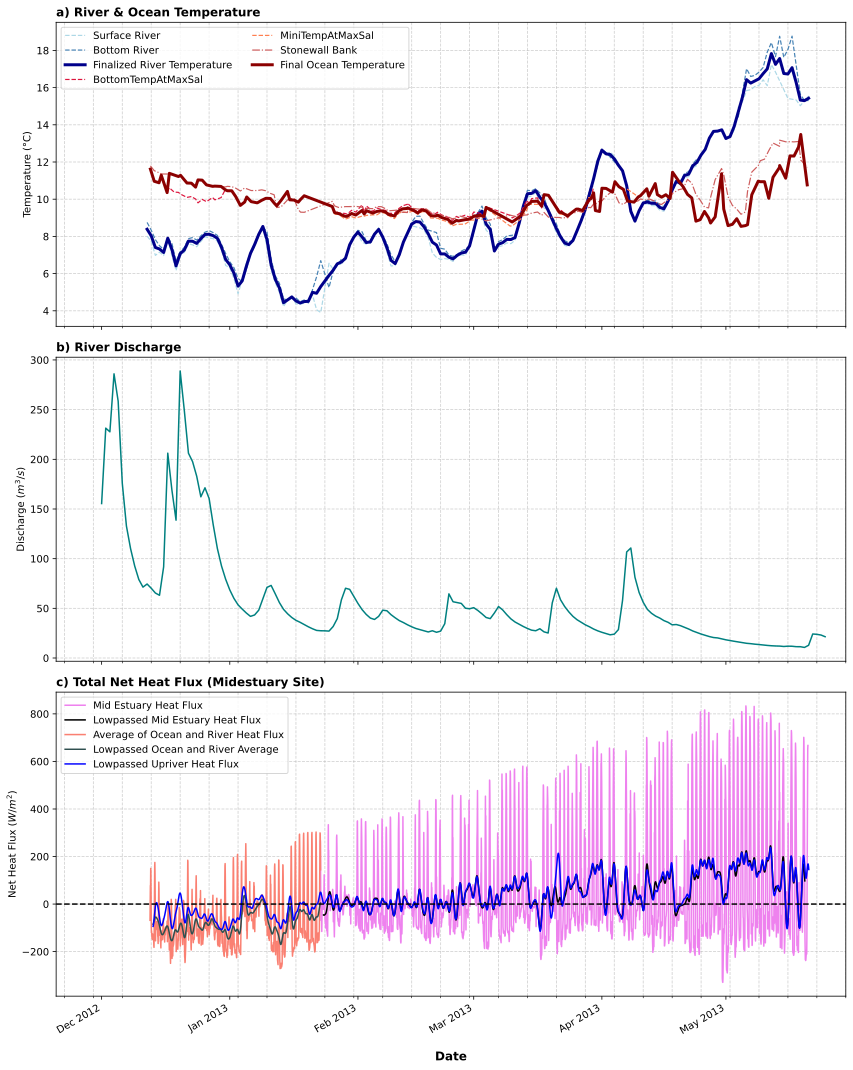

In [10]:
import pandas as pd
import scipy.io as sio
from scipy import signal
from scipy import stats
import numpy as np
import datetime
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
%config InlineBackend.figure_format = 'svg'

# --- Load Data ---
oceanDF = pd.read_csv('ocean_temperature12_13.csv', parse_dates = ['DN'])
riverDF = pd.read_csv('FINALIZED_river_temperature12_13.csv', parse_dates = ['dayDN'])
flowDF = pd.read_csv('adjustedflow1213.csv', parse_dates = ['date_only'])
midHeatFluxDF = pd.read_csv('mid_heatflux_2012-2013.csv', parse_dates = ['Tm (UTC)'])
AvgHeatFluxDF = pd.read_csv('12_13_substituted_heatflux.csv', parse_dates = ['Tm (UTC)'])
upHeatFluxDF = pd.read_csv('upriver1213_heatflux.csv', parse_dates = ['Tm (UTC)'])

# --- Find Global Min/Max Dates for Axis Alignment ---
min_date = min(riverDF['dayDN'].min(), oceanDF['DN'].min(), midHeatFluxDF['Tm (UTC)'].min(), AvgHeatFluxDF['Tm (UTC)'].min())
max_date = max(riverDF['dayDN'].max(), oceanDF['DN'].max(), midHeatFluxDF['Tm (UTC)'].max(), AvgHeatFluxDF['Tm (UTC)'].max())

# --- Setup Figure and Subplots ---
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.35) 
# Set X-Axis Limits (Applied across all subplots via sharex=True)
axs[0].set_xlim(pd.Timestamp("2012-11-20 00:00:00"), pd.Timestamp("2013-05-30 00:00:00"))

date_form = mdates.DateFormatter('%b %d %Y')

# -------------------------------------------------------------------------
# Subplot a) Combined River and Ocean Temperature
# -------------------------------------------------------------------------
axs[0].plot(riverDF['dayDN'], riverDF['surfaceRiver'], label='Surface River', color='lightblue', linestyle='--', linewidth=1.2)
axs[0].plot(riverDF['dayDN'], riverDF['bottomRiver'], label='Bottom River', color='steelblue', linestyle='--', linewidth=1.2)
axs[0].plot(riverDF['dayDN'], riverDF['EstimatedTemp'], label='Finalized River Temperature', color='darkblue', linewidth=3.0)

axs[0].plot(oceanDF['DN'], oceanDF['BottomTemp'], label='BottomTempAtMaxSal', color='crimson', linestyle='--', linewidth=1.2)
axs[0].plot(oceanDF['DN'], oceanDF['Temperature'], label='MiniTempAtMaxSal', color='coral', linestyle='--', linewidth=1.2)
axs[0].plot(oceanDF['DN'], oceanDF['dailyAverage'], label='Stonewall Bank', color='indianred', linestyle='-.', linewidth=1.2)
axs[0].plot(oceanDF['DN'], oceanDF['AvgEstimatedTemp'], label='Final Ocean Temperature', color='darkred', linewidth=3.0)

axs[0].set_title('a) River & Ocean Temperature', loc='left', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Temperature (°C)')
axs[0].legend(loc='upper left', ncol=2)


# -------------------------------------------------------------------------
# Subplot b) River Discharge
# -------------------------------------------------------------------------
axs[1].plot(flowDF['date_only'], flowDF['fRate'], color='teal', linewidth=1.5)

axs[1].set_title('b) River Discharge', loc='left', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Discharge ($m^3/s$)') 

# -------------------------------------------------------------------------
# Subplot c) Total Net Heat Flux
# -------------------------------------------------------------------------
axs[2].plot(midHeatFluxDF['Tm (UTC)'], midHeatFluxDF['Qnet'], color='violet', linewidth=1.5)
axs[2].plot(midHeatFluxDF['Tm (UTC)'], midHeatFluxDF['lowpass'], color='black', linewidth=1.5)
axs[2].plot(AvgHeatFluxDF['Tm (UTC)'], AvgHeatFluxDF['Qnet'], color='salmon', linewidth=1.5)
axs[2].plot(AvgHeatFluxDF['Tm (UTC)'], AvgHeatFluxDF['lowpass'], color='darkslategray', linewidth=1.5)
axs[2].plot(upHeatFluxDF['Tm (UTC)'], upHeatFluxDF['lowpass'], color='blue', linewidth=1.5)

# Add horizontal zero line
axs[2].axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=10)

axs[2].legend(['Mid Estuary Heat Flux', 'Lowpassed Mid Estuary Heat Flux', 'Average of Ocean and River Heat Flux', 'Lowpassed Ocean and River Average', 'Lowpassed Upriver Heat Flux'], loc='upper left', ncol=1)

axs[2].set_title('c) Total Net Heat Flux (Midestuary Site)', loc='left', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Net Heat Flux ($W/m^2$)')

axs[2].set_xlabel('Date', fontsize=12)
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

# -------------------------------------------------------------------------
# Axis Formatting, Rotation, and Timeline Synchronization
# -------------------------------------------------------------------------

# Set 7-day minor ticks for vertical gridlines across all subplots
for ax in axs:
    ax.grid(True, which='major', axis = 'y', linestyle='--', alpha=0.6)
    
    # 7-day interval for minor vertical gridlines along the x-axis
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7))
    ax.grid(True, which='minor', axis='x', linestyle='--', alpha=0.6)

axs[2].set_xlabel('Date', fontweight='bold', labelpad=15)

plt.tight_layout()
plt.show() 